In [31]:
import pandas as pd
import os

current_dir = os.path.abspath('.')
root_dir = os.path.dirname(current_dir) 
file_path = os.path.join(root_dir, 'data', 'default of credit card clients.csv')
    
# Charger le CSV dans un DataFrame
df = pd.read_csv(file_path)


In [32]:
df = df.set_index('ID')
print(df.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']


In [33]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [34]:
# Créer la liste des colonnes à analyser
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== ANALYSE DES RETARDS DE PAIEMENT ===")

# Analyser chaque colonne de paiement
results = {}
total_records = len(df)

for col in pay_columns:
    # Compter les valeurs strictement inférieures à -1
    count_less_than_neg1 = (df[col] < -1).sum()
    percentage_less_than_neg1 = (count_less_than_neg1 / total_records) * 100
    
    # Compter les valeurs égales à 0
    count_zeros = (df[col] == 0).sum()
    percentage_zeros = (count_zeros / total_records) * 100
    
    # Statistiques générales
    min_val = df[col].min()
    max_val = df[col].max()
    mean_val = df[col].mean()
    
    results[col] = {
        'count_less_than_neg1': count_less_than_neg1,
        'percentage_less_than_neg1': percentage_less_than_neg1,
        'count_zeros': count_zeros,
        'percentage_zeros': percentage_zeros,
        'min': min_val,
        'max': max_val,
        'mean': mean_val
    }
    
    print(f"\n{col}:")
    print(f"  - Nombre de valeurs < -1: {count_less_than_neg1}")
    print(f"  - Pourcentage < -1: {percentage_less_than_neg1:.2f}%")
    print(f"  - Nombre de valeurs = 0: {count_zeros}")
    print(f"  - Pourcentage = 0: {percentage_zeros:.2f}%")
    print(f"  - Valeur minimale: {min_val}")
    print(f"  - Valeur maximale: {max_val}")
    print(f"  - Moyenne: {mean_val:.2f}")
    
    # Afficher quelques exemples de valeurs < -1
    if count_less_than_neg1 > 0:
        negative_values = df[df[col] < -1][col].head()
        print(f"  - Exemples (< -1): {negative_values.tolist()}")

print("\n=== ANALYSE SPÉCIFIQUE ===")
print("Nombre de valeurs strictement inférieures à -1 dans chaque colonne :")

total_negative = 0
total_zeros = 0

for col in pay_columns:
    count_negative = (df[col] < -1).sum()
    count_zero = (df[col] == 0).sum()
    
    total_negative += count_negative
    total_zeros += count_zero
    
    print(f"  {col}: {count_negative} valeurs < -1, {count_zero} valeurs = 0")

print(f"\nTotal de toutes les valeurs < -1: {total_negative}")
print(f"Total de toutes les valeurs = 0: {total_zeros}")
    

=== ANALYSE DES RETARDS DE PAIEMENT ===

PAY_1:
  - Nombre de valeurs < -1: 2759
  - Pourcentage < -1: 9.20%
  - Nombre de valeurs = 0: 14737
  - Pourcentage = 0: 49.12%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.02
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_2:
  - Nombre de valeurs < -1: 3782
  - Pourcentage < -1: 12.61%
  - Nombre de valeurs = 0: 15730
  - Pourcentage = 0: 52.43%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.13
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_3:
  - Nombre de valeurs < -1: 4085
  - Pourcentage < -1: 13.62%
  - Nombre de valeurs = 0: 15764
  - Pourcentage = 0: 52.55%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.17
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_4:
  - Nombre de valeurs < -1: 4348
  - Pourcentage < -1: 14.49%
  - Nombre de valeurs = 0: 16455
  - Pourcentage = 0: 54.85%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.22
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_

In [35]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_neg2 = df[pay_columns].eq(-2).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des -2 : {count_all_neg2}")

Nombre de lignes contenant uniquement des -2 : 2109


In [36]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_neg2 = df[pay_columns].eq(-2).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un -2 : {count_at_least_one_neg2}")

Nombre de lignes contenant au moins un -2 : 6561


In [37]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_neg1 = df[pay_columns].eq(-1).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des -1 : {count_all_neg1}")

Nombre de lignes contenant uniquement des -1 : 1992


In [38]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_neg1 = df[pay_columns].eq(-2).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un -1 : {count_at_least_one_neg1}")

Nombre de lignes contenant au moins un -1 : 6561


In [39]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_0 = df[pay_columns].eq(0).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des 0 : {count_all_0}")

Nombre de lignes contenant uniquement des 0 : 9821


In [40]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_0 = df[pay_columns].eq(0).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un 0 : {count_at_least_one_0}")

Nombre de lignes contenant au moins un 0 : 21173


### approche de compréhention  
Je cherche à comprendre à quoi correspondent les valeurs '-2', '-1' et '0' des colonnes 'PAY_n'.  
Ces 3 valeurs signifient-elles la même chose ? Représentent-elles des retards mal saisis ?  
Selon la documentation du dataset, '-1' signifie client à jour et des entiers positifs représentent le nombre de mois de retard de paiement  
Je regarde pour ces 3 valeurs à quoi cela peut correspondre en terme de paiements et d'encours

In [41]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES VALEURS DE PAIEMENT ===")
print("Correspondance entre les valeurs de PAY_n et les moyennes de BILL_AMT_n")

# Pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    print(f"\n--- {pay_col} vs {bill_amt_col} ---")
    
    # Calculer les moyennes pour chaque valeur spécifique
    # Valeur 0
    if (df[pay_col] == 0).sum() > 0:
        mean_for_zero = df[df[pay_col] == 0][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = 0 : {mean_for_zero:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    # Valeur -1
    if (df[pay_col] == -1).sum() > 0:
        mean_for_neg1 = df[df[pay_col] == -1][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = -1 : {mean_for_neg1:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    # Valeur -2
    if (df[pay_col] == -2).sum() > 0:
        mean_for_neg2 = df[df[pay_col] == -2][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = -2 : {mean_for_neg2:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Afficher quelques exemples pour chaque valeur
    print("  Exemples de valeurs dans la colonne BILL_AMT :")
    if (df[pay_col] == 0).sum() > 0:
        examples_zero = df[df[pay_col] == 0][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = 0 : {examples_zero.tolist()}")
    
    if (df[pay_col] == -1).sum() > 0:
        examples_neg1 = df[df[pay_col] == -1][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = -1 : {examples_neg1.tolist()}")
    
    if (df[pay_col] == -2).sum() > 0:
        examples_neg2 = df[df[pay_col] == -2][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = -2 : {examples_neg2.tolist()}")

print("\n=== ANALYSE DES VALEURS DE PAIEMENT (PAY_AMT) ===")
print("Correspondance entre les valeurs de PAY_n et les moyennes de PAY_AMT_n")

# Pour chaque paire de colonnes PAY_AMT
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    
    print(f"\n--- {pay_col} vs {pay_amt_col} ---")
    
    # Calculer les moyennes pour chaque valeur spécifique
    # Valeur 0
    if (df[pay_col] == 0).sum() > 0:
        mean_for_zero = df[df[pay_col] == 0][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = 0 : {mean_for_zero:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    # Valeur -1
    if (df[pay_col] == -1).sum() > 0:
        mean_for_neg1 = df[df[pay_col] == -1][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = -1 : {mean_for_neg1:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    # Valeur -2
    if (df[pay_col] == -2).sum() > 0:
        mean_for_neg2 = df[df[pay_col] == -2][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = -2 : {mean_for_neg2:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Afficher quelques exemples pour chaque valeur
    print("  Exemples de valeurs dans la colonne PAY_AMT :")
    if (df[pay_col] == 0).sum() > 0:
        examples_zero = df[df[pay_col] == 0][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = 0 : {examples_zero.tolist()}")
    
    if (df[pay_col] == -1).sum() > 0:
        examples_neg1 = df[df[pay_col] == -1][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = -1 : {examples_neg1.tolist()}")
    
    if (df[pay_col] == -2).sum() > 0:
        examples_neg2 = df[df[pay_col] == -2][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = -2 : {examples_neg2.tolist()}")

print("\n=== STATISTIQUES GÉNÉRALES ===")
# Afficher les statistiques générales pour chaque colonne
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    print(f"\n{pay_col} :")
    print(f"  - Moyenne de {bill_amt_col} : {df[bill_amt_col].mean():.2f}")
    print(f"  - Écart-type de {bill_amt_col} : {df[bill_amt_col].std():.2f}")
    print(f"  - Nombre total de valeurs : {len(df)}")

=== ANALYSE DES VALEURS DE PAIEMENT ===
Correspondance entre les valeurs de PAY_n et les moyennes de BILL_AMT_n

--- PAY_1 vs BILL_AMT2 ---
  Moyenne de BILL_AMT2 quand PAY_1 = 0 : 74238.19
  Moyenne de BILL_AMT2 quand PAY_1 = -1 : 11038.78
  Moyenne de BILL_AMT2 quand PAY_1 = -2 : 8610.32
  Exemples de valeurs dans la colonne BILL_AMT :
    Valeurs BILL_AMT2 pour PAY_1 = 0 : [14027, 48233, 57069]
    Valeurs BILL_AMT2 pour PAY_1 = -1 : [1725, 5670, 21670]
    Valeurs BILL_AMT2 pour PAY_1 = -2 : [0, 19420, 4152]

--- PAY_2 vs BILL_AMT3 ---
  Moyenne de BILL_AMT3 quand PAY_2 = 0 : 69525.15
  Moyenne de BILL_AMT3 quand PAY_2 = -1 : 11559.09
  Moyenne de BILL_AMT3 quand PAY_2 = -2 : 6625.60
  Exemples de valeurs dans la colonne BILL_AMT :
    Valeurs BILL_AMT3 pour PAY_2 = 0 : [13559, 49291, 35835]
    Valeurs BILL_AMT3 pour PAY_2 = -1 : [601, 9966, 316]
    Valeurs BILL_AMT3 pour PAY_2 = -2 : [0, 0, 0]

--- PAY_3 vs BILL_AMT4 ---
  Moyenne de BILL_AMT4 quand PAY_3 = 0 : 64280.66
  Moyenn

Tendances à ce que les montants payés baissent quand PAY_n = -2  
C'est plus marquant sur l'encours, il diminue drastiquement en moyenne à mesure que PAY_n est négatif  
Je regarde la proportion de 0 ou négatifs dans les encours et les paiements

In [42]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES PROPORTIONS DE VALEURS NULLES ===")
print("Proportion de valeurs égales à 0 dans PAY_AMT et BILL_AMT pour chaque valeur de PAY_n")

# Analyse pour chaque colonne PAY_n
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    total_records = len(df)
    
    print(f"\n--- {pay_col} ---")
    
    # Pour chaque valeur de PAY_n, calculer la proportion de 0 dans PAY_AMT
    print(f"Proportion de 0 dans {pay_amt_col} :")
    if (df[pay_col] == 0).sum() > 0:
        count_zeros = (df[(df[pay_col] == 0) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_zero_pay = (df[pay_col] == 0).sum()
        percentage_zeros = (count_zeros / total_with_zero_pay) * 100 if total_with_zero_pay > 0 else 0
        print(f"  Quand {pay_col} = 0 : {count_zeros} sur {total_with_zero_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    if (df[pay_col] == -1).sum() > 0:
        count_zeros = (df[(df[pay_col] == -1) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_neg1_pay = (df[pay_col] == -1).sum()
        percentage_zeros = (count_zeros / total_with_neg1_pay) * 100 if total_with_neg1_pay > 0 else 0
        print(f"  Quand {pay_col} = -1 : {count_zeros} sur {total_with_neg1_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    if (df[pay_col] == -2).sum() > 0:
        count_zeros = (df[(df[pay_col] == -2) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_neg2_pay = (df[pay_col] == -2).sum()
        percentage_zeros = (count_zeros / total_with_neg2_pay) * 100 if total_with_neg2_pay > 0 else 0
        print(f"  Quand {pay_col} = -2 : {count_zeros} sur {total_with_neg2_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Même analyse pour BILL_AMT
    print(f"Proportion de <=0 dans {bill_amt_col} :")
    if (df[pay_col] == 0).sum() > 0:
        count_zeros = (df[(df[pay_col] == 0) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_zero_pay = (df[pay_col] == 0).sum()
        percentage_zeros = (count_zeros / total_with_zero_pay) * 100 if total_with_zero_pay > 0 else 0
        print(f"  Quand {pay_col} = 0 : {count_zeros} sur {total_with_zero_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    if (df[pay_col] == -1).sum() > 0:
        count_zeros = (df[(df[pay_col] == -1) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_neg1_pay = (df[pay_col] == -1).sum()
        percentage_zeros = (count_zeros / total_with_neg1_pay) * 100 if total_with_neg1_pay > 0 else 0
        print(f"  Quand {pay_col} = -1 : {count_zeros} sur {total_with_neg1_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    if (df[pay_col] == -2).sum() > 0:
        count_zeros = (df[(df[pay_col] == -2) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_neg2_pay = (df[pay_col] == -2).sum()
        percentage_zeros = (count_zeros / total_with_neg2_pay) * 100 if total_with_neg2_pay > 0 else 0
        print(f"  Quand {pay_col} = -2 : {count_zeros} sur {total_with_neg2_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")

print("\n=== ANALYSE COMPARATIVE ===")
print("Résumé des proportions de 0 pour chaque situation")

# Résumé par situation
situations = ['0', '-1', '-2']
for situation in situations:
    print(f"\n--- Situation {situation} ---")
    
    for i in range(len(pay_columns)):
        pay_col = pay_columns[i]
        pay_amt_col = pay_amt_columns[i]
        bill_amt_col = bill_amt_columns[i]
        
        if situation == '0':
            condition = df[pay_col] == 0
        elif situation == '-1':
            condition = df[pay_col] == -1
        else:  # situation == '-2'
            condition = df[pay_col] == -2
        
        total_with_situation = condition.sum()
        
        if total_with_situation > 0:
            # Pour PAY_AMT
            zeros_in_pay_amt = (condition & (df[pay_amt_col] == 0)).sum()
            percentage_pay_amt = (zeros_in_pay_amt / total_with_situation) * 100
            
            # Pour BILL_AMT
            zeros_in_bill_amt = (condition & (df[bill_amt_col] == 0)).sum()
            percentage_bill_amt = (zeros_in_bill_amt / total_with_situation) * 100
            
            print(f"  {pay_col}: PAY_AMT={percentage_pay_amt:.2f}%, BILL_AMT={percentage_bill_amt:.2f}%")

=== ANALYSE DES PROPORTIONS DE VALEURS NULLES ===
Proportion de valeurs égales à 0 dans PAY_AMT et BILL_AMT pour chaque valeur de PAY_n

--- PAY_1 ---
Proportion de 0 dans PAY_AMT1 :
  Quand PAY_1 = 0 : 261 sur 14737 (1.77%) de valeurs nulles dans PAY_AMT1
  Quand PAY_1 = -1 : 1022 sur 5686 (17.97%) de valeurs nulles dans PAY_AMT1
  Quand PAY_1 = -2 : 912 sur 2759 (33.06%) de valeurs nulles dans PAY_AMT1
Proportion de <=0 dans BILL_AMT2 :
  Quand PAY_1 = 0 : 282 sur 14737 (1.91%) de valeurs <=0 dans BILL_AMT2
  Quand PAY_1 = -1 : 703 sur 5686 (12.36%) de valeurs <=0 dans BILL_AMT2
  Quand PAY_1 = -2 : 952 sur 2759 (34.51%) de valeurs <=0 dans BILL_AMT2

--- PAY_2 ---
Proportion de 0 dans PAY_AMT2 :
  Quand PAY_2 = 0 : 1000 sur 15730 (6.36%) de valeurs nulles dans PAY_AMT2
  Quand PAY_2 = -1 : 1195 sur 6050 (19.75%) de valeurs nulles dans PAY_AMT2
  Quand PAY_2 = -2 : 1822 sur 3782 (48.18%) de valeurs nulles dans PAY_AMT2
Proportion de <=0 dans BILL_AMT3 :
  Quand PAY_2 = 0 : 542 sur 15

La proportion d'encours non utilisé augmente fortement à mesure que PAY_n est négatif  
Regardons à l'inverse : quelles valeurs de PAY_n quand PAY_AMT = 0 ou BIL_AMT <=0

In [43]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES TRANSITIONS INVERSES ===")
print("Répartition des valeurs de PAY_n-1 quand BILL_AMTn <= 0 ou PAY_AMTn-1 = 0")

# Analyse pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    # Pour chaque colonne PAY_n, on regarde la répartition des valeurs de la colonne précédente
    print(f"\n--- {pay_col} ---")
    
    # Analyse quand BILL_AMT_n <= 0
    print(f"Répartition de {pay_col} quand {bill_amt_col} <= 0 :")
    mask_bill_zero = df[bill_amt_col] <= 0
    count_with_bill_zero = mask_bill_zero.sum()
    
    if count_with_bill_zero > 0:
        # Compter la répartition des valeurs de la colonne précédente
        value_counts = df[mask_bill_zero][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / count_with_bill_zero) * 100
            print(f"  - {pay_col} = {value} : {count} sur {count_with_bill_zero} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} <= 0")
    
    # Analyse quand PAY_AMT_n-1 = 0
    print(f"Répartition de {pay_col} quand {pay_amt_col} = 0 :")
    mask_pay_zero = df[pay_amt_col] == 0
    count_with_pay_zero = mask_pay_zero.sum()
    
    if count_with_pay_zero > 0:
        # Compter la répartition des valeurs de la colonne précédente
        value_counts = df[mask_pay_zero][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / count_with_pay_zero) * 100
            print(f"  - {pay_col} = {value} : {count} sur {count_with_pay_zero} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {pay_amt_col} = 0")
       


=== ANALYSE DES TRANSITIONS INVERSES ===
Répartition des valeurs de PAY_n-1 quand BILL_AMTn <= 0 ou PAY_AMTn-1 = 0

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 <= 0 :
  - PAY_1 = -2 : 952 sur 3175 (29.98%)
  - PAY_1 = -1 : 703 sur 3175 (22.14%)
  - PAY_1 = 0 : 282 sur 3175 (8.88%)
  - PAY_1 = 1 : 1175 sur 3175 (37.01%)
  - PAY_1 = 2 : 63 sur 3175 (1.98%)
Répartition de PAY_1 quand PAY_AMT1 = 0 :
  - PAY_1 = -2 : 912 sur 5249 (17.37%)
  - PAY_1 = -1 : 1022 sur 5249 (19.47%)
  - PAY_1 = 0 : 261 sur 5249 (4.97%)
  - PAY_1 = 1 : 2190 sur 5249 (41.72%)
  - PAY_1 = 2 : 545 sur 5249 (10.38%)
  - PAY_1 = 3 : 199 sur 5249 (3.79%)
  - PAY_1 = 4 : 58 sur 5249 (1.10%)
  - PAY_1 = 5 : 23 sur 5249 (0.44%)
  - PAY_1 = 6 : 11 sur 5249 (0.21%)
  - PAY_1 = 7 : 9 sur 5249 (0.17%)
  - PAY_1 = 8 : 19 sur 5249 (0.36%)

--- PAY_2 ---
Répartition de PAY_2 quand BILL_AMT3 <= 0 :
  - PAY_2 = -2 : 1873 sur 3525 (53.13%)
  - PAY_2 = -1 : 920 sur 3525 (26.10%)
  - PAY_2 = 0 : 542 sur 3525 (15.38%)
  - PAY_2

Un phénomène incohérent au premier abord est visible ici : un retard est constaté alors qu'il n'y a pas d'encours, surtout en PAY_1. Le niveau de retard ne dépasse cependant jamais 2 mois, 2 possibilités à exploiter :
- anomalie dans la colonne PAY_n
- anomalie dans la colonne BILL_AMTn-1  
Pour ajuster mes théories, je vais regarder uniquement BILL_AMTn-1 == 0 et BILL_AMTn-1 < 0

In [44]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES TRANSITIONS INVERSES ===")
print("Répartition des valeurs de PAY_n-1 quand BILL_AMTn = 0")

# Analyse pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    # Pour chaque colonne PAY_n, on regarde la répartition des valeurs de la colonne précédente
    print(f"\n--- {pay_col} ---")
    
    # Analyse quand BILL_AMT_n <= 0
    print(f"Répartition de {pay_col} quand {bill_amt_col} = 0 :")
    mask_bill_zero = df[bill_amt_col] == 0
    count_with_bill_zero = mask_bill_zero.sum()
    
    if count_with_bill_zero > 0:
        # Compter la répartition des valeurs de la colonne précédente
        value_counts = df[mask_bill_zero][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / count_with_bill_zero) * 100
            print(f"  - {pay_col} = {value} : {count} sur {count_with_bill_zero} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} = 0")
    
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print('----------------------------------------------')
print("=== ANALYSE DES TRANSITIONS INVERSES ===")
print("Répartition des valeurs de PAY_n-1 quand BILL_AMTn < 0")

# Analyse pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    # Pour chaque colonne PAY_n, on regarde la répartition des valeurs de la colonne précédente
    print(f"\n--- {pay_col} ---")
    
    # Analyse quand BILL_AMT_n <= 0
    print(f"Répartition de {pay_col} quand {bill_amt_col} < 0 :")
    mask_bill_zero = df[bill_amt_col] == 0
    count_with_bill_zero = mask_bill_zero.sum()
    
    if count_with_bill_zero > 0:
        # Compter la répartition des valeurs de la colonne précédente
        value_counts = df[mask_bill_zero][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / count_with_bill_zero) * 100
            print(f"  - {pay_col} = {value} : {count} sur {count_with_bill_zero} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} < 0")


=== ANALYSE DES TRANSITIONS INVERSES ===
Répartition des valeurs de PAY_n-1 quand BILL_AMTn = 0

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 = 0 :
  - PAY_1 = -2 : 737 sur 2506 (29.41%)
  - PAY_1 = -1 : 526 sur 2506 (20.99%)
  - PAY_1 = 0 : 234 sur 2506 (9.34%)
  - PAY_1 = 1 : 957 sur 2506 (38.19%)
  - PAY_1 = 2 : 52 sur 2506 (2.08%)

--- PAY_2 ---
Répartition de PAY_2 quand BILL_AMT3 = 0 :
  - PAY_2 = -2 : 1555 sur 2870 (54.18%)
  - PAY_2 = -1 : 712 sur 2870 (24.81%)
  - PAY_2 = 0 : 461 sur 2870 (16.06%)
  - PAY_2 = 1 : 5 sur 2870 (0.17%)
  - PAY_2 = 2 : 137 sur 2870 (4.77%)

--- PAY_3 ---
Répartition de PAY_3 quand BILL_AMT4 = 0 :
  - PAY_3 = -2 : 1927 sur 3195 (60.31%)
  - PAY_3 = -1 : 697 sur 3195 (21.82%)
  - PAY_3 = 0 : 443 sur 3195 (13.87%)
  - PAY_3 = 2 : 128 sur 3195 (4.01%)

--- PAY_4 ---
Répartition de PAY_4 quand BILL_AMT5 = 0 :
  - PAY_4 = -2 : 2211 sur 3506 (63.06%)
  - PAY_4 = -1 : 718 sur 3506 (20.48%)
  - PAY_4 = 0 : 497 sur 3506 (14.18%)
  - PAY_4 = 2 : 80 sur 

Pour aller plus loin, j'ai besoin de voir les valeurs de PAY_n antérieures (<= 0 [à jour] ou > 0 [retard])

In [45]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# 1. Analyse pour BILL_AMT = 0
print("=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT = 0 ===")
for pay_col, bill_amt_col in zip(pay_columns, bill_amt_columns):
    print(f"\n--- {pay_col} ---")
    mask = df[bill_amt_col] == 0
    total = mask.sum()
    print(f"Répartition de {pay_col} quand {bill_amt_col} = 0 :")
    if total > 0:
        value_counts = df[mask][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"  - {pay_col} = {value} : {count} sur {total} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} = 0")

# 2. Analyse pour BILL_AMT < 0
print("\n----------------------------------------------")
print("=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT < 0 ===")
for pay_col, bill_amt_col in zip(pay_columns, bill_amt_columns):
    print(f"\n--- {pay_col} ---")
    mask = df[bill_amt_col] < 0  # Correction : ajout du < 0
    total = mask.sum()
    print(f"Répartition de {pay_col} quand {bill_amt_col} < 0 :")
    if total > 0:
        value_counts = df[mask][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"  - {pay_col} = {value} : {count} sur {total} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} < 0")

=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT = 0 ===

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 = 0 :
  - PAY_1 = -2 : 737 sur 2506 (29.41%)
  - PAY_1 = -1 : 526 sur 2506 (20.99%)
  - PAY_1 = 0 : 234 sur 2506 (9.34%)
  - PAY_1 = 1 : 957 sur 2506 (38.19%)
  - PAY_1 = 2 : 52 sur 2506 (2.08%)

--- PAY_2 ---
Répartition de PAY_2 quand BILL_AMT3 = 0 :
  - PAY_2 = -2 : 1555 sur 2870 (54.18%)
  - PAY_2 = -1 : 712 sur 2870 (24.81%)
  - PAY_2 = 0 : 461 sur 2870 (16.06%)
  - PAY_2 = 1 : 5 sur 2870 (0.17%)
  - PAY_2 = 2 : 137 sur 2870 (4.77%)

--- PAY_3 ---
Répartition de PAY_3 quand BILL_AMT4 = 0 :
  - PAY_3 = -2 : 1927 sur 3195 (60.31%)
  - PAY_3 = -1 : 697 sur 3195 (21.82%)
  - PAY_3 = 0 : 443 sur 3195 (13.87%)
  - PAY_3 = 2 : 128 sur 3195 (4.01%)

--- PAY_4 ---
Répartition de PAY_4 quand BILL_AMT5 = 0 :
  - PAY_4 = -2 : 2211 sur 3506 (63.06%)
  - PAY_4 = -1 : 718 sur 3506 (20.48%)
  - PAY_4 = 0 : 497 sur 3506 (14.18%)
  - PAY_4 = 2 : 80 sur 3506 (2.28%)

--- PAY_5 ---
Répartition 

nouvelle approche : regarder la valeur antérieure de PAY_n dans ces cas précis  

In [46]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# 1. Analyse pour BILL_AMT = 0
print("=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT = 0 ===")
for i, (pay_col, bill_amt_col) in enumerate(zip(pay_columns, bill_amt_columns)):
    print(f"\n--- {pay_col} ---")
    mask = df[bill_amt_col] == 0
    total = mask.sum()
    print(f"Répartition de {pay_col} quand {bill_amt_col} = 0 :")
    
    if total > 0:
        value_counts = df[mask][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"  - {pay_col} = {value} : {count} sur {total} ({percentage:.2f}%)")
            
            # Ajout de l'analyse de PAY_{n+1} si possible
            if i < len(pay_columns) - 1:  # Si ce n'est pas la dernière colonne
                next_pay_col = pay_columns[i + 1]
                print(f"    Proportions de {next_pay_col} pour les lignes où {pay_col} = {value} :")
                
                # Filtrer les lignes avec la valeur spécifique
                specific_mask = (df[bill_amt_col] == 0) & (df[pay_col] == value)
                next_total = specific_mask.sum()
                
                if next_total > 0:
                    # Calculer les proportions > 0 et <= 0 pour PAY_{n+1}
                    next_values = df[specific_mask][next_pay_col]
                    count_greater_zero = (next_values > 0).sum()
                    count_less_equal_zero = (next_values <= 0).sum()
                    
                    percentage_greater_zero = (count_greater_zero / next_total) * 100
                    percentage_less_equal_zero = (count_less_equal_zero / next_total) * 100
                    
                    print(f"      - {next_pay_col} > 0 : {count_greater_zero} sur {next_total} ({percentage_greater_zero:.2f}%)")
                    print(f"      - {next_pay_col} <= 0 : {count_less_equal_zero} sur {next_total} ({percentage_less_equal_zero:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} = 0")

print("\n----------------------------------------------")
print("=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT < 0 ===")

# 2. Analyse pour BILL_AMT < 0
for i, (pay_col, bill_amt_col) in enumerate(zip(pay_columns, bill_amt_columns)):
    print(f"\n--- {pay_col} ---")
    mask = df[bill_amt_col] < 0  # Correction : masque pour les valeurs strictement négatives
    total = mask.sum()
    print(f"Répartition de {pay_col} quand {bill_amt_col} < 0 :")
    
    if total > 0:
        value_counts = df[mask][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"  - {pay_col} = {value} : {count} sur {total} ({percentage:.2f}%)")
            
            # Ajout de l'analyse de PAY_{n+1} si possible
            if i < len(pay_columns) - 1:  # Si ce n'est pas la dernière colonne
                next_pay_col = pay_columns[i + 1]
                print(f"    Proportions de {next_pay_col} pour les lignes où {pay_col} = {value} :")
                
                # Filtrer les lignes avec la valeur spécifique
                specific_mask = (df[bill_amt_col] < 0) & (df[pay_col] == value)
                next_total = specific_mask.sum()
                
                if next_total > 0:
                    # Calculer les proportions > 0 et <= 0 pour PAY_{n+1}
                    next_values = df[specific_mask][next_pay_col]
                    count_greater_zero = (next_values > 0).sum()
                    count_less_equal_zero = (next_values <= 0).sum()
                    
                    percentage_greater_zero = (count_greater_zero / next_total) * 100
                    percentage_less_equal_zero = (count_less_equal_zero / next_total) * 100
                    
                    print(f"      - {next_pay_col} > 0 : {count_greater_zero} sur {next_total} ({percentage_greater_zero:.2f}%)")
                    print(f"      - {next_pay_col} <= 0 : {count_less_equal_zero} sur {next_total} ({percentage_less_equal_zero:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} < 0")

=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT = 0 ===

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 = 0 :
  - PAY_1 = -2 : 737 sur 2506 (29.41%)
    Proportions de PAY_2 pour les lignes où PAY_1 = -2 :
      - PAY_2 > 0 : 0 sur 737 (0.00%)
      - PAY_2 <= 0 : 737 sur 737 (100.00%)
  - PAY_1 = -1 : 526 sur 2506 (20.99%)
    Proportions de PAY_2 pour les lignes où PAY_1 = -1 :
      - PAY_2 > 0 : 0 sur 526 (0.00%)
      - PAY_2 <= 0 : 526 sur 526 (100.00%)
  - PAY_1 = 0 : 234 sur 2506 (9.34%)
    Proportions de PAY_2 pour les lignes où PAY_1 = 0 :
      - PAY_2 > 0 : 0 sur 234 (0.00%)
      - PAY_2 <= 0 : 234 sur 234 (100.00%)
  - PAY_1 = 1 : 957 sur 2506 (38.19%)
    Proportions de PAY_2 pour les lignes où PAY_1 = 1 :
      - PAY_2 > 0 : 6 sur 957 (0.63%)
      - PAY_2 <= 0 : 951 sur 957 (99.37%)
  - PAY_1 = 2 : 52 sur 2506 (2.08%)
    Proportions de PAY_2 pour les lignes où PAY_1 = 2 :
      - PAY_2 > 0 : 52 sur 52 (100.00%)
      - PAY_2 <= 0 : 0 sur 52 (0.00%)

--- PAY_2 ---

      - PAY_5 > 0 : 0 sur 2211 (0.00%)
      - PAY_5 <= 0 : 2211 sur 2211 (100.00%)
  - PAY_4 = -1 : 718 sur 3506 (20.48%)
    Proportions de PAY_5 pour les lignes où PAY_4 = -1 :
      - PAY_5 > 0 : 0 sur 718 (0.00%)
      - PAY_5 <= 0 : 718 sur 718 (100.00%)
  - PAY_4 = 0 : 497 sur 3506 (14.18%)
    Proportions de PAY_5 pour les lignes où PAY_4 = 0 :
      - PAY_5 > 0 : 0 sur 497 (0.00%)
      - PAY_5 <= 0 : 497 sur 497 (100.00%)
  - PAY_4 = 2 : 80 sur 3506 (2.28%)
    Proportions de PAY_5 pour les lignes où PAY_4 = 2 :
      - PAY_5 > 0 : 38 sur 80 (47.50%)
      - PAY_5 <= 0 : 42 sur 80 (52.50%)

--- PAY_5 ---
Répartition de PAY_5 quand BILL_AMT6 = 0 :
  - PAY_5 = -2 : 2411 sur 4020 (59.98%)
  - PAY_5 = -1 : 772 sur 4020 (19.20%)
  - PAY_5 = 0 : 790 sur 4020 (19.65%)
  - PAY_5 = 2 : 47 sur 4020 (1.17%)

----------------------------------------------
=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT < 0 ===

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 < 0 :
  - PAY_1 = -2 : 215

In [47]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== RÉPARTITION DES VALEURS DANS LES COLONNES PAY_N ===")

# Calcul de la répartition pour chaque colonne
for col in pay_columns:
    print(f"\n--- {col} ---")
    value_counts = df[col].value_counts().sort_index()
    
    for value, count in value_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  - Valeur {value} : {count} sur {len(df)} ({percentage:.2f}%)")

print(f"\n=== RÉPARTITION CUMULÉE DE TOUTES LES COLONNES PAY_N ===")

# Répartition cumulative de toutes les valeurs
all_values = []
value_counts_cumul = {}

for col in pay_columns:
    values = df[col].value_counts()
    for value, count in values.items():
        if value not in value_counts_cumul:
            value_counts_cumul[value] = 0
        value_counts_cumul[value] += count

# Afficher la répartition cumulative
total_rows = len(df)
for value in sorted(value_counts_cumul.keys()):
    percentage = (value_counts_cumul[value] / total_rows) * 100 /6
    print(f"  - Valeur {value} : {value_counts_cumul[value]} sur {total_rows} ({percentage:.2f}%)")

=== RÉPARTITION DES VALEURS DANS LES COLONNES PAY_N ===

--- PAY_1 ---
  - Valeur -2 : 2759 sur 30000 (9.20%)
  - Valeur -1 : 5686 sur 30000 (18.95%)
  - Valeur 0 : 14737 sur 30000 (49.12%)
  - Valeur 1 : 3688 sur 30000 (12.29%)
  - Valeur 2 : 2667 sur 30000 (8.89%)
  - Valeur 3 : 322 sur 30000 (1.07%)
  - Valeur 4 : 76 sur 30000 (0.25%)
  - Valeur 5 : 26 sur 30000 (0.09%)
  - Valeur 6 : 11 sur 30000 (0.04%)
  - Valeur 7 : 9 sur 30000 (0.03%)
  - Valeur 8 : 19 sur 30000 (0.06%)

--- PAY_2 ---
  - Valeur -2 : 3782 sur 30000 (12.61%)
  - Valeur -1 : 6050 sur 30000 (20.17%)
  - Valeur 0 : 15730 sur 30000 (52.43%)
  - Valeur 1 : 28 sur 30000 (0.09%)
  - Valeur 2 : 3927 sur 30000 (13.09%)
  - Valeur 3 : 326 sur 30000 (1.09%)
  - Valeur 4 : 99 sur 30000 (0.33%)
  - Valeur 5 : 25 sur 30000 (0.08%)
  - Valeur 6 : 12 sur 30000 (0.04%)
  - Valeur 7 : 20 sur 30000 (0.07%)
  - Valeur 8 : 1 sur 30000 (0.00%)

--- PAY_3 ---
  - Valeur -2 : 4085 sur 30000 (13.62%)
  - Valeur -1 : 5938 sur 30000 (19.7

Ici, le taux de défaut (codification 2) est divisé par 2,5 en cas d'encours nul ou négatif.  


J'ai besoin de 'voir' des lignes de données pour comprendre le fonctionnement de ce dataset, de la banque

In [48]:
mask = (df['PAY_5'] == 2) & (df['BILL_AMT6'] <= 0)
df[mask].head(15)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
1289,20000,2,3,1,48,1,2,2,3,2,...,17055,10400,0,2700,1400,0,0,0,0,1
1630,50000,1,3,2,31,0,0,0,0,2,...,38286,37543,0,1566,2000,3800,0,1546,0,0
4982,240000,1,3,1,43,-1,-1,2,2,2,...,2500,2500,0,2500,0,0,0,0,0,1
5513,200000,2,3,1,69,2,2,2,2,2,...,2500,0,0,0,0,0,0,0,0,1
5732,200000,2,1,2,48,-2,-2,-2,-1,2,...,5000,5000,0,0,0,5000,0,0,0,0
6156,30000,2,1,2,24,-1,-1,-1,-1,2,...,323,158,-1027,165,165,323,0,0,5527,1
7323,360000,1,2,1,30,2,2,2,2,2,...,2500,0,0,0,0,0,0,0,0,1
8106,500000,2,1,1,34,-2,-2,-1,2,2,...,3500,0,0,0,3500,0,0,0,0,1
9692,130000,2,1,2,29,-1,3,2,2,2,...,78,78,-121,0,0,0,0,0,0,0


La mise à jour de PAY_n lors d'un incident ou d'une régularisation ne semble pas toujours immédiate

In [49]:
df.head(20)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
6,50000,1,1,2,37,0,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
7,500000,1,1,2,29,0,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
8,100000,2,2,2,23,0,-1,-1,0,0,...,221,-159,567,380,601,0,581,1687,1542,0
9,140000,2,3,1,28,0,0,2,0,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0


=== HISTOGRAMMES DES VALEURS PAY_N ===


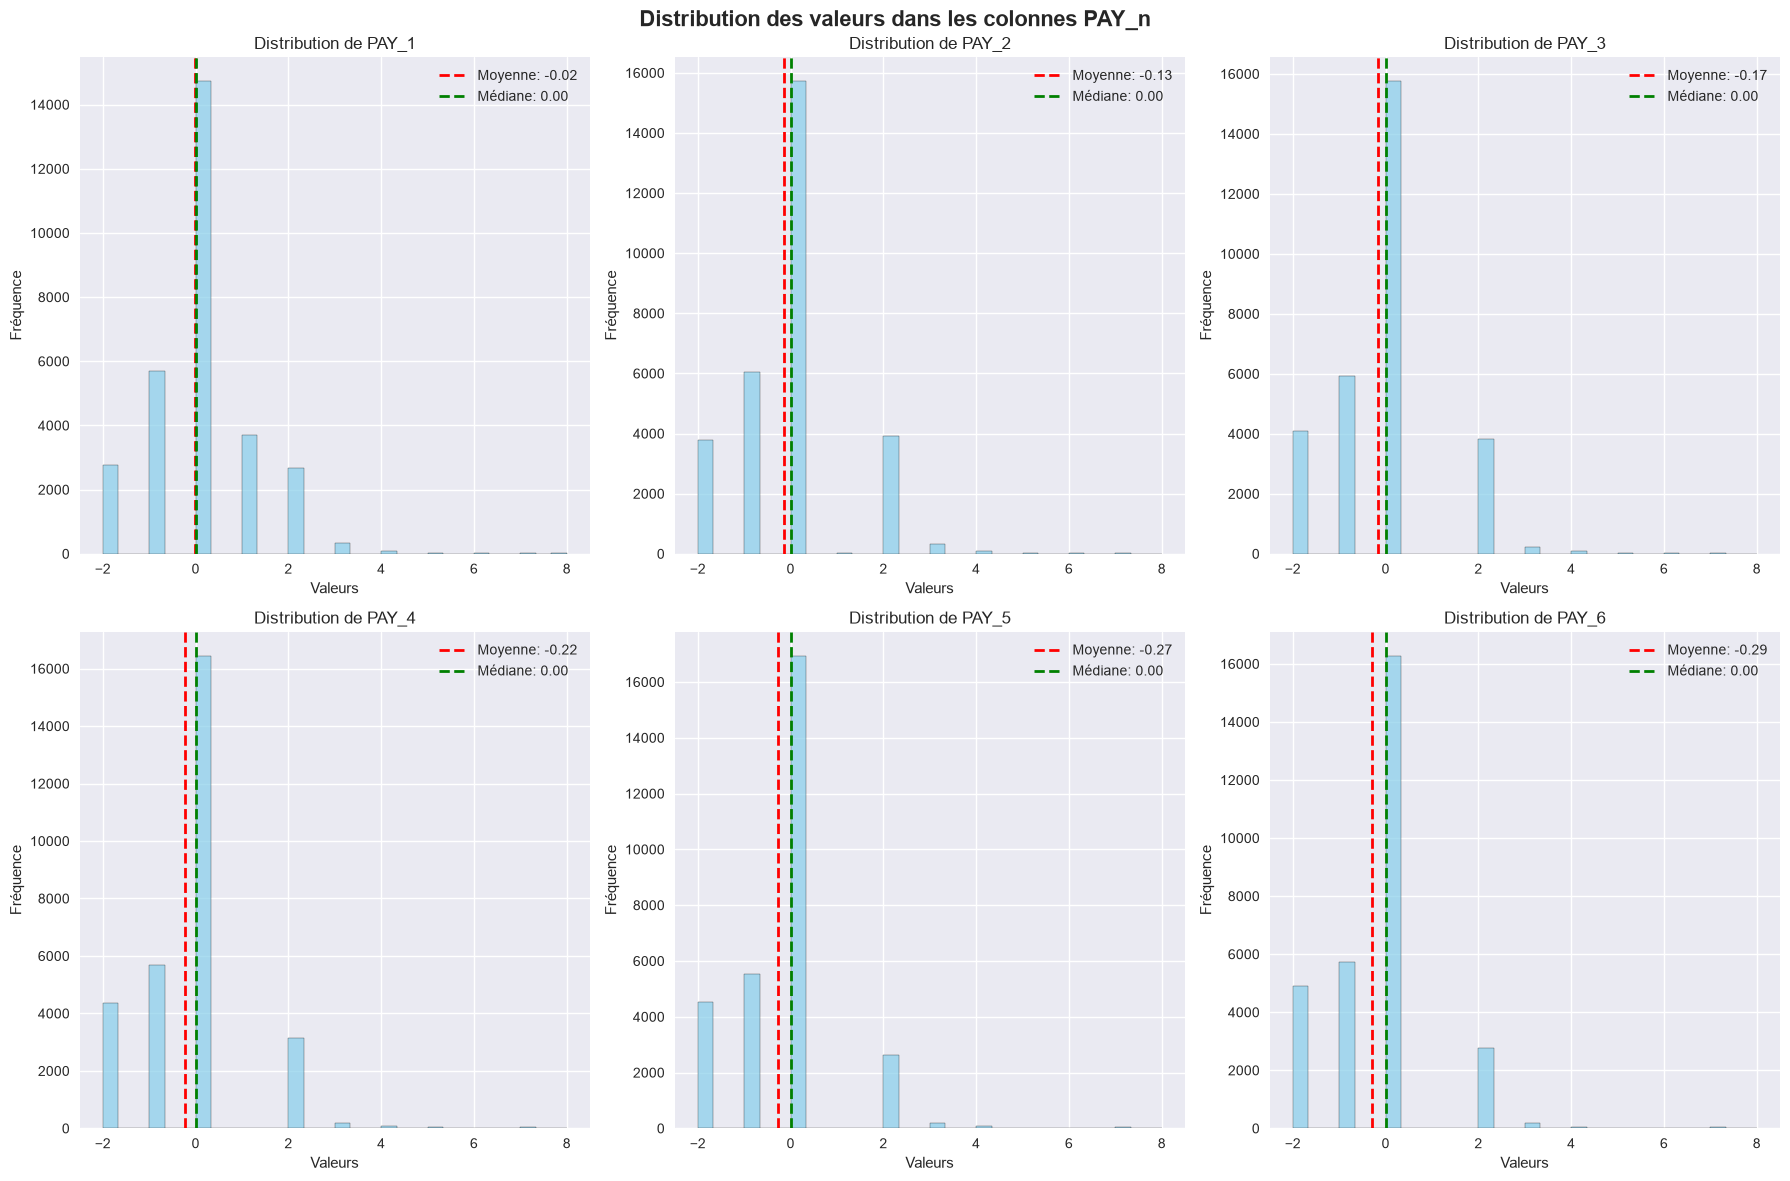


=== HISTOGRAMME CUMULÉ ===


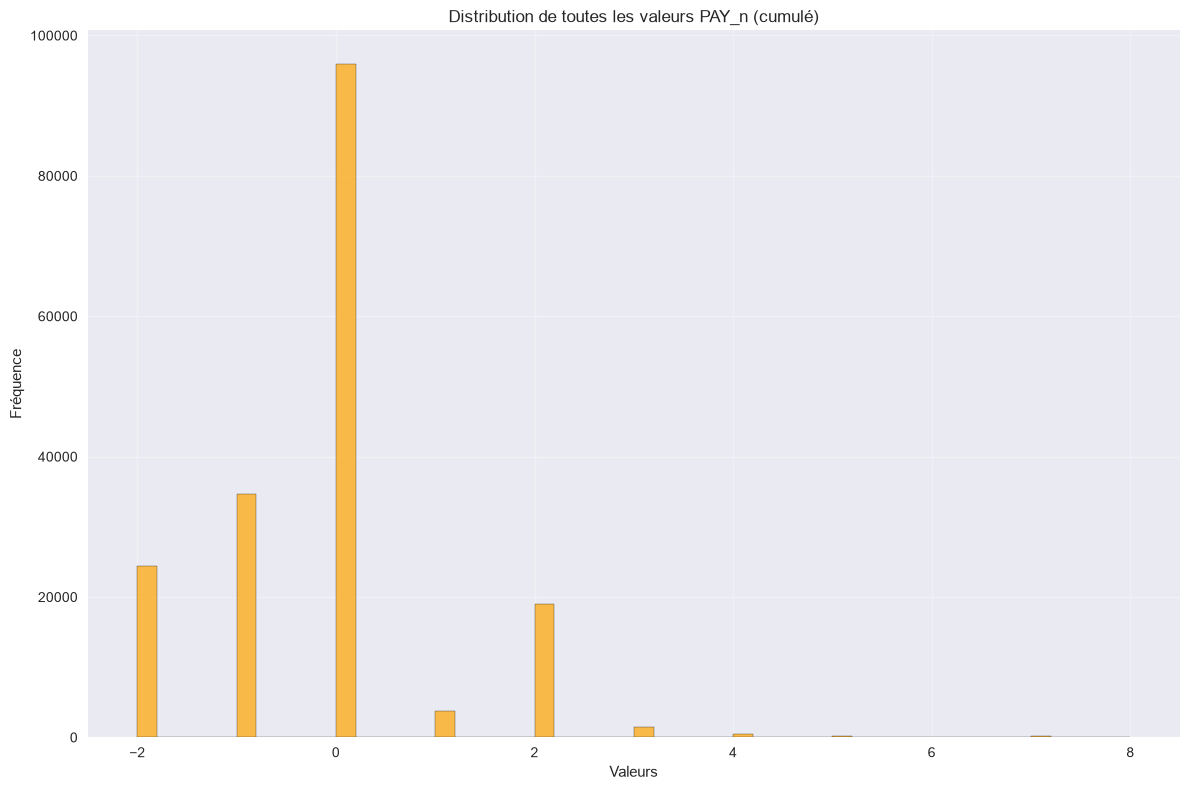

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== HISTOGRAMMES DES VALEURS PAY_N ===")

# Configuration du style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution des valeurs dans les colonnes PAY_n', fontsize=16, fontweight='bold')

# Création des histogrammes pour chaque colonne
for i, col in enumerate(pay_columns):
    row = i // 3
    col_idx = i % 3
    
    # Filtrer les valeurs non nulles pour l'histogramme
    data = df[col].dropna()
    
    axes[row, col_idx].hist(data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[row, col_idx].set_title(f'Distribution de {col}')
    axes[row, col_idx].set_xlabel('Valeurs')
    axes[row, col_idx].set_ylabel('Fréquence')
    
    # Ajout des statistiques
    mean_val = data.mean()
    median_val = data.median()
    axes[row, col_idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                              label=f'Moyenne: {mean_val:.2f}')
    axes[row, col_idx].axvline(median_val, color='green', linestyle='--', linewidth=2, 
                              label=f'Médiane: {median_val:.2f}')
    axes[row, col_idx].legend()

# Cacher l'axe vide si nécessaire
if len(pay_columns) < 6:
    axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

print("\n=== HISTOGRAMME CUMULÉ ===")
# Histogramme cumulé de toutes les colonnes - CORRECTION
fig, ax = plt.subplots(figsize=(12, 8))

# Rassembler toutes les valeurs (pas de cumulative=True)
all_values = []
for col in pay_columns:
    all_values.extend(df[col].dropna())

# Créer l'histogramme standard avec toutes les données
ax.hist(all_values, bins=50, alpha=0.7, color='orange', edgecolor='black')
ax.set_title('Distribution de toutes les valeurs PAY_n (cumulé)')
ax.set_xlabel('Valeurs')
ax.set_ylabel('Fréquence')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

la valeur '1' dans PAY_n est clairement sous représentée  
quelques exemples dans le dataset au dessus montre qu'un dossier sain passe en incident directement à 2  
2 dossiers sains sans encours passent également au statut 'incident 1', ce qui semble être une réelle anomalie

In [51]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
mask = (df[pay_columns] == 1).any(axis=1)
df[mask].head(20)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
14,70000,1,2,2,30,1,2,2,0,0,...,66782,36137,36894,3200,0,3000,3000,1500,0,1
16,50000,2,3,3,23,1,2,0,0,0,...,28771,29531,30211,0,1500,1100,1200,1300,1100,0
19,360000,2,1,1,49,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
20,180000,2,1,2,29,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
27,60000,1,1,2,27,1,-2,-1,-1,-1,...,-57,127,-189,0,1000,0,500,0,1000,1
39,50000,1,1,2,25,1,-1,-1,-2,-2,...,0,0,0,780,0,0,0,0,0,1
51,70000,1,3,2,42,1,2,2,2,2,...,39423,38659,39362,0,3100,2000,0,1500,1500,1
54,180000,2,1,2,25,1,2,0,0,0,...,43510,44420,45319,1300,2010,1762,1762,1790,1622,0
69,130000,2,3,2,29,1,-2,-2,-1,2,...,10311,10161,7319,0,0,20161,0,7319,13899,0


In [52]:
pay_columns = ['PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
mask = (df[pay_columns] == 1).any(axis=1)
df[mask]

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
892,400000,1,2,2,37,1,1,1,2,0,...,12599,18599,12284,3019,5014,3,7040,2006,2005,0
1967,90000,1,2,1,29,1,1,1,0,0,...,2442,48063,48186,3100,1000,770,48012,1756,1894,0
5645,500000,1,1,1,42,1,1,0,0,0,...,163299,159110,135658,1054,177080,4425,5666,4825,100225,0
6025,210000,2,2,2,29,1,1,-2,-2,-1,...,-1987,1697,4347,0,0,2000,4000,3000,5000,0
6118,80000,1,1,2,26,1,1,-2,-2,-2,...,0,0,0,5000,0,0,0,0,0,0
6783,500000,1,1,1,32,1,1,1,1,0,...,64178,64992,50722,20000,20012,10036,15000,10000,50000,0
8616,270000,2,2,2,53,1,1,-2,-2,-2,...,-4,-19205,42418,2,2,6002,2,64446,5002,0
9120,50000,1,2,2,40,1,1,-1,-1,0,...,29148,30270,22814,0,2931,30000,5270,2814,3089,0
11013,20000,2,2,2,45,1,1,-1,0,-1,...,8005,3034,9287,700,21400,1005,3034,9287,85,0


In [53]:
# Compte le nombre de '1' dans chaque colonne PAY_n
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== COMPTAGE DES VALEURS '1' DANS CHAQUE COLONNE PAY_N ===")

# Compter le nombre de 1 dans chaque colonne
column_counts = {}
total_ones = 0

for col in pay_columns:
    count = (df[col] == 1).sum()
    column_counts[col] = count
    total_ones += count
    percentage = (count / len(df)) * 100
    print(f"{col} : {count} sur {len(df)} ({percentage:.2f}%)")


=== COMPTAGE DES VALEURS '1' DANS CHAQUE COLONNE PAY_N ===
PAY_1 : 3688 sur 30000 (12.29%)
PAY_2 : 28 sur 30000 (0.09%)
PAY_3 : 4 sur 30000 (0.01%)
PAY_4 : 2 sur 30000 (0.01%)
PAY_5 : 0 sur 30000 (0.00%)
PAY_6 : 0 sur 30000 (0.00%)


PAY_1 contient beaucoup de '1' alors que cette valeur est qausi absente des autres colonnes, et nombre d'entre eux ne sont pas justifiés  
Avant de tenter un nettoyage, je constate une tendance de codification légèrement différente de ce qui est décrit dans la documentation  
Si on écarte les erreurs humaines, informatiques et autres, il se dégage une certaine tendance concernant les valeurs de PAY_n :
- -2 correspond à des comptes majoritairement inactifs
- -1 et 0 correspondent à des comptes ayant un fonctionnement sain ne présentant pas de retard
- 1 correspond à une sorte d'alerte sur le compte (fin d'un retard, activation ou réactivation d'un compte), il ne semble pas forcemment correspondre à une échéance de retard
- 2 et + correspondent à des comptes avec retards, en effet un incident fait basculer la note directement à 2
Ces indications sont très importantes pour la représentation des ensembles et la creéations des features pour les futurs modèles de prédiction  
Dans le cas ou 1 signifie que la banque a reçu une information interne ou externe concernant le compte, il apparaît délicat de corriger cette colonne.

Le défaut de paiement futur 'dpnm' est de 22% dans le dataset.  
Une banque ne survivrait pas plusieurs mois avec un taux de défaillance aussi élevé, on peut s'interroger sur l'origine du dataset et de son éventuel biais, surtout mis en relation avec la forte proportion de PAY_1 = 1.  
Ceci est à mettre dans le contexte suivant : une crise importante a eu lieu en 2005 à Taïwan sur le crédit avec un emballement soudain de son usage et du taux de défaut.

In [54]:
# Afficher la proportion de dpnm == 1 alors que BILL_AMT1 <= 0
print("=== ANALYSE DE dpnm LORSQUE BILL_AMT1 <= 0 ===")

# Création des masques
mask_bill_zero = df['BILL_AMT1'] <= 0
total_with_bill_zero = mask_bill_zero.sum()

print(f"Nombre total de lignes où BILL_AMT1 <= 0 : {total_with_bill_zero}")

if total_with_bill_zero > 0:
    # Proportion de dpnm == 1 dans ces lignes
    mask_dpnm_one = (df['BILL_AMT1'] <= 0) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_bill_zero) * 100
    
    print(f"Nombre de lignes où BILL_AMT1 <= 0 ET dpnm == 1 : {count_dpnm_one}")
    print(f"Proportion de dpnm == 1 parmi les lignes où BILL_AMT1 <= 0 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask_bill_zero]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où BILL_AMT1 <= 0 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_bill_zero) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_bill_zero} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    print(f"Nombre total de lignes : {total_dataset}")
    print(f"Répartition globale de dpnm :")
    for value, count in dpnm_global.items():
        percentage = (count / total_dataset) * 100
        print(f"  - dpnm = {value} : {count} sur {total_dataset} ({percentage:.2f}%)")
    
    print(f"\n=== ANALYSE DÉTAILLÉE ===")
    # Calcul des proportions dans les deux cas
    if total_with_bill_zero > 0:
        print(f"Pourcentage de dpnm = 1 dans les lignes avec BILL_AMT1 <= 0 : {percentage_dpnm_one:.2f}%")
        print(f"Pourcentage de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
    
    # Afficher quelques exemples de lignes
    print(f"\n=== EXEMPLES DE LIGNES ===")
    sample_rows = df[mask_bill_zero].head(5)
    print("Premières lignes où BILL_AMT1 <= 0 :")
    print(sample_rows[['BILL_AMT1', 'dpnm']])
    
else:
    print("Aucune ligne ne correspond à la condition BILL_AMT1 <= 0")

print("\n=== ANALYSE COMPARATIVE ===")
# Comparaison avec d'autres conditions
conditions = [
    ("BILL_AMT1 <= 0", df['BILL_AMT1'] <= 0),
    ("BILL_AMT1 > 0", df['BILL_AMT1'] > 0),
    ("BILL_AMT1 < 0", df['BILL_AMT1'] < 0)
]

for condition_name, condition_mask in conditions:
    if condition_mask.sum() > 0:
        dpnm_counts = df[condition_mask]['dpnm'].value_counts()
        print(f"\n{condition_name} :")
        for value, count in dpnm_counts.items():
            percentage = (count / condition_mask.sum()) * 100
            print(f"  - dpnm = {value} : {count} sur {condition_mask.sum()} ({percentage:.2f}%)")

=== ANALYSE DE dpnm LORSQUE BILL_AMT1 <= 0 ===
Nombre total de lignes où BILL_AMT1 <= 0 : 2598
Nombre de lignes où BILL_AMT1 <= 0 ET dpnm == 1 : 643
Proportion de dpnm == 1 parmi les lignes où BILL_AMT1 <= 0 : 24.75%

Répartition complète de dpnm pour les lignes où BILL_AMT1 <= 0 :
  - dpnm = 0 : 1955 sur 2598 (75.25%)
  - dpnm = 1 : 643 sur 2598 (24.75%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Nombre total de lignes : 30000
Répartition globale de dpnm :
  - dpnm = 0 : 23364 sur 30000 (77.88%)
  - dpnm = 1 : 6636 sur 30000 (22.12%)

=== ANALYSE DÉTAILLÉE ===
Pourcentage de dpnm = 1 dans les lignes avec BILL_AMT1 <= 0 : 24.75%
Pourcentage de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 2.63%

=== EXEMPLES DE LIGNES ===
Premières lignes où BILL_AMT1 <= 0 :
    BILL_AMT1  dpnm
ID                 
10          0     0
19          0     0
20          0     0
27       -109     1
39          0     1

=== ANALYSE COMPARATIVE ===

BILL_AMT1 <= 0 :
  - dpn

Ces résultats sont extrêmement illogiques, une banque ne peut pas avoir un incident de paiement futur sans encours.  
Cela est surtout un bruit conséquent que les modèles ne pourront pas atténuer. De plus, pour une banque, c'est la sécurisation de l'encours réel qui compte

In [55]:
# Afficher la proportion de dpnm == 1 alors que TOUS les BILL_AMTn < 0
print("=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn < 0 ===")

# Création des listes de colonnes
bill_amt_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Trouver les lignes où TOUS les BILL_AMTn sont < 0
mask_all_bill_neg = df[bill_amt_columns].lt(0).all(axis=1)
total_with_all_bill_neg = mask_all_bill_neg.sum()

print(f"Nombre total de lignes où TOUS les BILL_AMTn < 0 : {total_with_all_bill_neg}")

if total_with_all_bill_neg > 0:
    # Proportion de dpnm == 1 dans ces lignes
    mask_dpnm_one = (df[bill_amt_columns].lt(0).all(axis=1)) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_all_bill_neg) * 100
    
    print(f"Nombre de lignes où TOUS les BILL_AMTn < 0 ET dpnm == 1 : {count_dpnm_one}")
    print(f"Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn < 0 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask_all_bill_neg]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où TOUS les BILL_AMTn < 0 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_all_bill_neg) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_all_bill_neg} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    print(f"Nombre total de lignes : {total_dataset}")
    print(f"Répartition globale de dpnm :")
    for value, count in dpnm_global.items():
        percentage = (count / total_dataset) * 100
        print(f"  - dpnm = {value} : {count} sur {total_dataset} ({percentage:.2f}%)")
    
    print(f"\n=== ANALYSE DÉTAILLÉE ===")
    # Calcul des proportions dans les deux cas
    if total_with_all_bill_neg > 0:
        print(f"Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn < 0 : {percentage_dpnm_one:.2f}%")
        print(f"Pourcentage de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
    
    # Afficher quelques exemples de lignes
    print(f"\n=== EXEMPLES DE LIGNES ===")
    sample_rows = df[mask_all_bill_neg].head(5)
    print("Premières lignes où TOUS les BILL_AMTn < 0 :")
    print(sample_rows[['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'dpnm']])
else:
    print("Aucune ligne ne correspond à la condition TOUS les BILL_AMTn < 0")

print("\n=== ANALYSE COMPARATIVE ===")
# Comparaison avec d'autres conditions
conditions = [
    ("TOUS les BILL_AMTn < 0", df[bill_amt_columns].lt(0).all(axis=1)),
    ("AU MOINS UN BILL_AMTn < 0", df[bill_amt_columns].lt(0).any(axis=1)),
    ("TOUS les BILL_AMTn > 0", df[bill_amt_columns].gt(0).all(axis=1))
]

for condition_name, condition_mask in conditions:
    if condition_mask.sum() > 0:
        dpnm_counts = df[condition_mask]['dpnm'].value_counts()
        print(f"\n{condition_name} :")
        for value, count in dpnm_counts.items():
            percentage = (count / condition_mask.sum()) * 100
            print(f"  - dpnm = {value} : {count} sur {condition_mask.sum()} ({percentage:.2f}%)")

=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn < 0 ===
Nombre total de lignes où TOUS les BILL_AMTn < 0 : 88
Nombre de lignes où TOUS les BILL_AMTn < 0 ET dpnm == 1 : 26
Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn < 0 : 29.55%

Répartition complète de dpnm pour les lignes où TOUS les BILL_AMTn < 0 :
  - dpnm = 0 : 62 sur 88 (70.45%)
  - dpnm = 1 : 26 sur 88 (29.55%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Nombre total de lignes : 30000
Répartition globale de dpnm :
  - dpnm = 0 : 23364 sur 30000 (77.88%)
  - dpnm = 1 : 6636 sur 30000 (22.12%)

=== ANALYSE DÉTAILLÉE ===
Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn < 0 : 29.55%
Pourcentage de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 7.43%

=== EXEMPLES DE LIGNES ===
Premières lignes où TOUS les BILL_AMTn < 0 :
     BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  dpnm
ID                                                              
110       -103    

In [56]:
# Afficher la proportion de dpnm == 1 alors que TOUS les BILL_AMTn == 0
print("=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn == 0 ===")

# Création des listes de colonnes
bill_amt_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Trouver les lignes où TOUS les BILL_AMTn sont == 0
mask_all_bill_zero = df[bill_amt_columns].eq(0).all(axis=1)
total_with_all_bill_zero = mask_all_bill_zero.sum()

print(f"Nombre total de lignes où TOUS les BILL_AMTn == 0 : {total_with_all_bill_zero}")

if total_with_all_bill_zero > 0:
    # Proportion de dpnm == 1 dans ces lignes
    mask_dpnm_one = (df[bill_amt_columns].eq(0).all(axis=1)) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_all_bill_zero) * 100
    
    print(f"Nombre de lignes où TOUS les BILL_AMTn == 0 ET dpnm == 1 : {count_dpnm_one}")
    print(f"Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn == 0 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask_all_bill_zero]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où TOUS les BILL_AMTn == 0 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_all_bill_zero) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_all_bill_zero} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    print(f"Nombre total de lignes : {total_dataset}")
    print(f"Répartition globale de dpnm :")
    for value, count in dpnm_global.items():
        percentage = (count / total_dataset) * 100
        print(f"  - dpnm = {value} : {count} sur {total_dataset} ({percentage:.2f}%)")
    
    print(f"\n=== ANALYSE DÉTAILLÉE ===")
    # Calcul des proportions dans les deux cas
    if total_with_all_bill_zero > 0:
        print(f"Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn == 0 : {percentage_dpnm_one:.2f}%")
        print(f"Pourcentage de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
    
    # Afficher quelques exemples de lignes
    print(f"\n=== EXEMPLES DE LIGNES ===")
    sample_rows = df[mask_all_bill_zero].head(5)
    print("Premières lignes où TOUS les BILL_AMTn == 0 :")
    print(sample_rows[['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'dpnm']])
    
else:
    print("Aucune ligne ne correspond à la condition TOUS les BILL_AMTn == 0")

print("\n=== ANALYSE COMPARATIVE ===")
# Comparaison avec d'autres conditions
conditions = [
    ("TOUS les BILL_AMTn == 0", df[bill_amt_columns].eq(0).all(axis=1)),
    ("TOUS les BILL_AMTn <= 0", df[bill_amt_columns].le(0).all(axis=1)),
    ("AU MOINS UN BILL_AMTn == 0", df[bill_amt_columns].eq(0).any(axis=1)),
    ("TOUS les BILL_AMTn > 0", df[bill_amt_columns].gt(0).all(axis=1))
]

for condition_name, condition_mask in conditions:
    if condition_mask.sum() > 0:
        dpnm_counts = df[condition_mask]['dpnm'].value_counts()
        print(f"\n{condition_name} :")
        for value, count in dpnm_counts.items():
            percentage = (count / condition_mask.sum()) * 100
            print(f"  - dpnm = {value} : {count} sur {condition_mask.sum()} ({percentage:.2f}%)")

=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn == 0 ===
Nombre total de lignes où TOUS les BILL_AMTn == 0 : 866
Nombre de lignes où TOUS les BILL_AMTn == 0 ET dpnm == 1 : 317
Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn == 0 : 36.61%

Répartition complète de dpnm pour les lignes où TOUS les BILL_AMTn == 0 :
  - dpnm = 0 : 549 sur 866 (63.39%)
  - dpnm = 1 : 317 sur 866 (36.61%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Nombre total de lignes : 30000
Répartition globale de dpnm :
  - dpnm = 0 : 23364 sur 30000 (77.88%)
  - dpnm = 1 : 6636 sur 30000 (22.12%)

=== ANALYSE DÉTAILLÉE ===
Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn == 0 : 36.61%
Pourcentage de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 14.49%

=== EXEMPLES DE LIGNES ===
Premières lignes où TOUS les BILL_AMTn == 0 :
     BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  dpnm
ID                                                              
19  

Aucune information n'existe sur internet ni dans l'étude originelle de 2009 sur ces incidents de paiement qui ne semblent pas concerner un encours. Si on raisonne logique métier, nous cherchons à sécuriser un encours et à prévoir le défaut de paiement réel.  
Il conviendra donc de ne pas inclure ces comptes inactifs dans les modèles d'apprentissage et de ne pas prédire le risque de défaut sur un crédit non utilisé.

Je repars sur la codification '1' dans PAY_n pour comprendre la logique et éventuellement envisager un nettoyage.  
Je regarde ce qui précède PAY_n = 1 et ce qui suit PAY_n = 1

In [57]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== RÉPARTITION DES VALEURS DE PAY_n+1 QUAND PAY_n = 1 ===")

# Pour chaque colonne PAY_n (sauf la dernière)
for i in range(len(pay_columns) - 1):
    current_pay = pay_columns[i]
    next_pay = pay_columns[i + 1]
    
    print(f"\n--- {current_pay} = 1 → {next_pay} ---")
    
    # Créer le masque pour les lignes où PAY_n = 1
    mask = df[current_pay] == 1
    total_with_current_pay_one = mask.sum()
    
    if total_with_current_pay_one > 0:
        print(f"Nombre de lignes où {current_pay} = 1 : {total_with_current_pay_one}")
        
        # Calculer la répartition des valeurs de PAY_{n+1}
        value_counts = df[mask][next_pay].value_counts().sort_index()
        
        print(f"Répartition de {next_pay} dans ces lignes :")
        for value, count in value_counts.items():
            percentage = (count / total_with_current_pay_one) * 100
            print(f"  - {next_pay} = {value} : {count} sur {total_with_current_pay_one} ({percentage:.2f}%)")
        
        # Afficher quelques statistiques supplémentaires
        next_values = df[mask][next_pay]
        print(f"  - Moyenne de {next_pay} : {next_values.mean():.2f}")
        print(f"  - Médiane de {next_pay} : {next_values.median():.2f}")
        print(f"  - Écart-type de {next_pay} : {next_values.std():.2f}")
        
    else:
        print(f"Aucune ligne où {current_pay} = 1")

print("\n=== ANALYSE COMPARATIVE ===")
print("Comparaison des répartitions entre les différents mois")

# Comparaison des répartitions
for i in range(len(pay_columns) - 1):
    current_pay = pay_columns[i]
    next_pay = pay_columns[i + 1]
    
    # Calculer la proportion de chaque valeur de PAY_{n+1} parmi les lignes où PAY_n = 1
    mask = df[current_pay] == 1
    total_with_current_pay_one = mask.sum()
    
    if total_with_current_pay_one > 0:
        value_counts = df[mask][next_pay].value_counts().sort_index()
        print(f"\n{current_pay} = 1 → {next_pay} :")
        for value, count in value_counts.items():
            percentage = (count / total_with_current_pay_one) * 100
            print(f"  - {value} : {percentage:.2f}%")

print("\n=== RÉSUMÉ GLOBAL ===")
print("Nombre de lignes avec PAY_n = 1 pour chaque colonne :")

# Afficher le nombre de lignes avec chaque valeur de PAY_n
for pay_col in pay_columns:
    count = (df[pay_col] == 1).sum()
    percentage = (count / len(df)) * 100
    print(f"  {pay_col} = 1 : {count} sur {len(df)} ({percentage:.2f}%)")

=== RÉPARTITION DES VALEURS DE PAY_n+1 QUAND PAY_n = 1 ===

--- PAY_1 = 1 → PAY_2 ---
Nombre de lignes où PAY_1 = 1 : 3688
Répartition de PAY_2 dans ces lignes :
  - PAY_2 = -2 : 1221 sur 3688 (33.11%)
  - PAY_2 = -1 : 612 sur 3688 (16.59%)
  - PAY_2 = 0 : 3 sur 3688 (0.08%)
  - PAY_2 = 1 : 28 sur 3688 (0.76%)
  - PAY_2 = 2 : 1672 sur 3688 (45.34%)
  - PAY_2 = 3 : 109 sur 3688 (2.96%)
  - PAY_2 = 4 : 32 sur 3688 (0.87%)
  - PAY_2 = 5 : 7 sur 3688 (0.19%)
  - PAY_2 = 6 : 2 sur 3688 (0.05%)
  - PAY_2 = 7 : 1 sur 3688 (0.03%)
  - PAY_2 = 8 : 1 sur 3688 (0.03%)
  - Moyenne de PAY_2 : 0.23
  - Médiane de PAY_2 : 1.00
  - Écart-type de PAY_2 : 1.94

--- PAY_2 = 1 → PAY_3 ---
Nombre de lignes où PAY_2 = 1 : 28
Répartition de PAY_3 dans ces lignes :
  - PAY_3 = -2 : 12 sur 28 (42.86%)
  - PAY_3 = -1 : 9 sur 28 (32.14%)
  - PAY_3 = 0 : 1 sur 28 (3.57%)
  - PAY_3 = 1 : 4 sur 28 (14.29%)
  - PAY_3 = 2 : 2 sur 28 (7.14%)
  - Moyenne de PAY_3 : -0.89
  - Médiane de PAY_3 : -1.00
  - Écart-type de P

In [58]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== RÉPARTITION DES VALEURS DE PAY_n-1 QUAND PAY_n = 1 ===")

# Pour chaque colonne PAY_n (sauf la première)
for i in range(1, len(pay_columns)):  # Commence à 1 pour pouvoir accéder à PAY_{n-1}
    current_pay = pay_columns[i]
    prev_pay = pay_columns[i - 1]
    
    print(f"\n--- {current_pay} = 1 → {prev_pay} ---")
    
    # Créer le masque pour les lignes où PAY_n = 1
    mask = df[current_pay] == 1
    total_with_current_pay_one = mask.sum()
    
    if total_with_current_pay_one > 0:
        print(f"Nombre de lignes où {current_pay} = 1 : {total_with_current_pay_one}")
        
        # Calculer la répartition des valeurs de PAY_{n-1}
        value_counts = df[mask][prev_pay].value_counts().sort_index()
        
        print(f"Répartition de {prev_pay} dans ces lignes :")
        for value, count in value_counts.items():
            percentage = (count / total_with_current_pay_one) * 100
            print(f"  - {prev_pay} = {value} : {count} sur {total_with_current_pay_one} ({percentage:.2f}%)")
        
        # Afficher quelques statistiques supplémentaires
        prev_values = df[mask][prev_pay]
        print(f"  - Moyenne de {prev_pay} : {prev_values.mean():.2f}")
        print(f"  - Médiane de {prev_pay} : {prev_values.median():.2f}")
        print(f"  - Écart-type de {prev_pay} : {prev_values.std():.2f}")
        
    else:
        print(f"Aucune ligne où {current_pay} = 1")

print("\n=== RÉSUMÉ GLOBAL ===")
print("Nombre de lignes avec PAY_n = 1 pour chaque colonne :")

# Afficher le nombre de lignes avec chaque valeur de PAY_n
for pay_col in pay_columns:
    count = (df[pay_col] == 1).sum()
    percentage = (count / len(df)) * 100
    print(f"  {pay_col} = 1 : {count} sur {len(df)} ({percentage:.2f}%)")



=== RÉPARTITION DES VALEURS DE PAY_n-1 QUAND PAY_n = 1 ===

--- PAY_2 = 1 → PAY_1 ---
Nombre de lignes où PAY_2 = 1 : 28
Répartition de PAY_1 dans ces lignes :
  - PAY_1 = 1 : 28 sur 28 (100.00%)
  - Moyenne de PAY_1 : 1.00
  - Médiane de PAY_1 : 1.00
  - Écart-type de PAY_1 : 0.00

--- PAY_3 = 1 → PAY_2 ---
Nombre de lignes où PAY_3 = 1 : 4
Répartition de PAY_2 dans ces lignes :
  - PAY_2 = 1 : 4 sur 4 (100.00%)
  - Moyenne de PAY_2 : 1.00
  - Médiane de PAY_2 : 1.00
  - Écart-type de PAY_2 : 0.00

--- PAY_4 = 1 → PAY_3 ---
Nombre de lignes où PAY_4 = 1 : 2
Répartition de PAY_3 dans ces lignes :
  - PAY_3 = 1 : 2 sur 2 (100.00%)
  - Moyenne de PAY_3 : 1.00
  - Médiane de PAY_3 : 1.00
  - Écart-type de PAY_3 : 0.00

--- PAY_5 = 1 → PAY_4 ---
Aucune ligne où PAY_5 = 1

--- PAY_6 = 1 → PAY_5 ---
Aucune ligne où PAY_6 = 1

=== RÉSUMÉ GLOBAL ===
Nombre de lignes avec PAY_n = 1 pour chaque colonne :
  PAY_1 = 1 : 3688 sur 30000 (12.29%)
  PAY_2 = 1 : 28 sur 30000 (0.09%)
  PAY_3 = 1 : 4 sur

PAY_n = 1 apparait majoritairement sur des comptes inactifs ou en impayés  
Quand PAY_n =1, PAY_n-1 = 1  
Cela confirme le statut de valeur d'alerte ou pré alerte. Cela peut être aussi un compte en instance de fermeture, de gel...

In [59]:
print("=== TAUX DE dpnm = 1 QUAND PAY_1 = 1 ===")

# Analyse pour PAY_1 = 1
current_pay = 'PAY_1'
mask = df[current_pay] == 1
total_with_current_pay_one = mask.sum()

print(f"Nombre total de lignes où {current_pay} = 1 : {total_with_current_pay_one}")

if total_with_current_pay_one > 0:
    # Calcul du taux de dpnm = 1
    mask_dpnm_one = (df[current_pay] == 1) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_current_pay_one) * 100
    
    print(f"Nombre de lignes où {current_pay} = 1 ET dpnm = 1 : {count_dpnm_one}")
    print(f"Taux de dpnm = 1 parmi les lignes où {current_pay} = 1 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où {current_pay} = 1 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_current_pay_one) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_current_pay_one} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    # Calcul des proportions dans les deux cas
    if total_with_current_pay_one > 0:
        print(f"Taux de dpnm = 1 dans les lignes où {current_pay} = 1 : {percentage_dpnm_one:.2f}%")
        print(f"Taux de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
       
else:
    print(f"Aucune ligne ne correspond à la condition {current_pay} = 1")

print("\n=== RÉSUMÉ DES RÉPARTITIONS ===")
# Répartition globale des valeurs de PAY_1
pay1_distribution = df['PAY_1'].value_counts().sort_index()
print("Répartition de PAY_1 :")
for value, count in pay1_distribution.items():
    percentage = (count / len(df)) * 100
    print(f"  - PAY_1 = {value} : {count} sur {len(df)} ({percentage:.2f}%)")

=== TAUX DE dpnm = 1 QUAND PAY_1 = 1 ===
Nombre total de lignes où PAY_1 = 1 : 3688
Nombre de lignes où PAY_1 = 1 ET dpnm = 1 : 1252
Taux de dpnm = 1 parmi les lignes où PAY_1 = 1 : 33.95%

Répartition complète de dpnm pour les lignes où PAY_1 = 1 :
  - dpnm = 0 : 2436 sur 3688 (66.05%)
  - dpnm = 1 : 1252 sur 3688 (33.95%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Taux de dpnm = 1 dans les lignes où PAY_1 = 1 : 33.95%
Taux de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 11.83%

=== RÉSUMÉ DES RÉPARTITIONS ===
Répartition de PAY_1 :
  - PAY_1 = -2 : 2759 sur 30000 (9.20%)
  - PAY_1 = -1 : 5686 sur 30000 (18.95%)
  - PAY_1 = 0 : 14737 sur 30000 (49.12%)
  - PAY_1 = 1 : 3688 sur 30000 (12.29%)
  - PAY_1 = 2 : 2667 sur 30000 (8.89%)
  - PAY_1 = 3 : 322 sur 30000 (1.07%)
  - PAY_1 = 4 : 76 sur 30000 (0.25%)
  - PAY_1 = 5 : 26 sur 30000 (0.09%)
  - PAY_1 = 6 : 11 sur 30000 (0.04%)
  - PAY_1 = 7 : 9 sur 30000 (0.03%)
  - PAY_1 = 8 : 19 sur 30000 (0.06%)

Un tableau de dispersion ici n'a pas beaucoup d'intéret.  
Je fais un heatmap.  

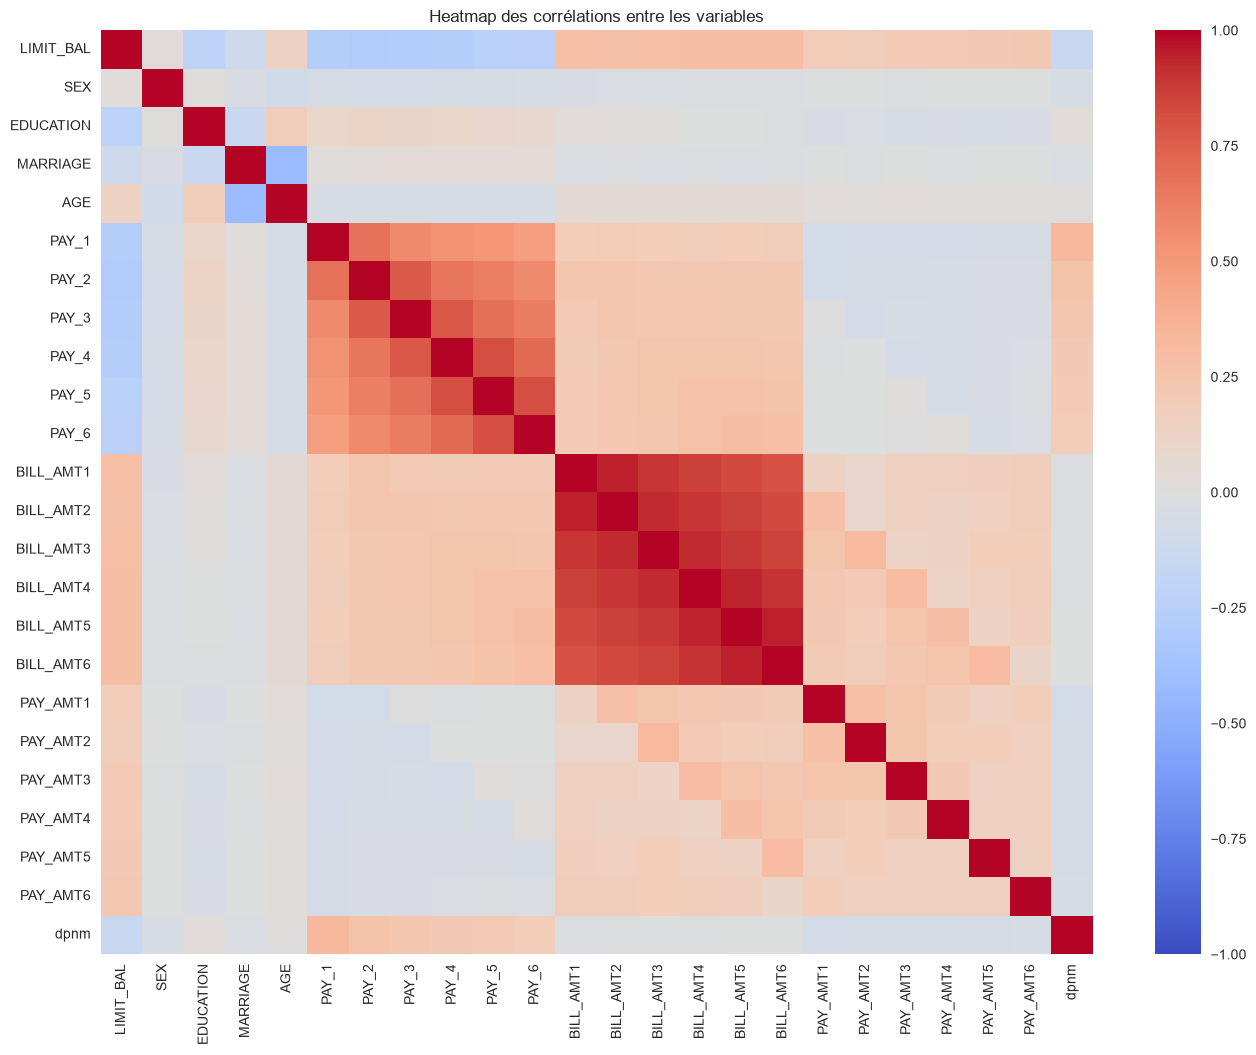

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assurez-vous que 'df' est votre DataFrame contenant les variables mentionnées
# Exemple : df = pd.read_csv('votre_fichier.csv')

# Sélectionner les variables pour la heatmap
variables = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 
             'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 
             'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']

# Calculer la matrice de corrélation
correlation_matrix = df[variables].corr()

# Créer la heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap des corrélations entre les variables')
plt.show()

on voit des tendances, parfois contre intuitives :
- le défaut de paiement est plus important sur les plus petits plafond de crédit
- le défaut de paiement est directement lié avec le retard d'échéances
- les retards de paiement sont plus importants/fréquents quand l'encours augmente

y a t il un seuil de montant payé ou montant payé / encours à partir duquel la banque considère l'échéance payée ?